In [21]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure

Ejercicio 1

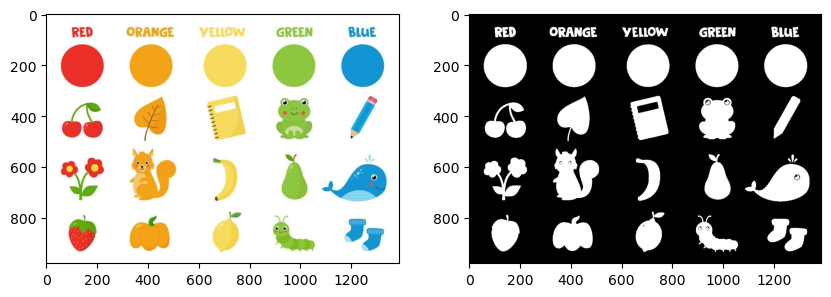

In [31]:
from skimage import measure

def conunt (img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  _,binarizada = cv2.threshold(img_gray, 230,255,cv2.THRESH_BINARY_INV)
  contorno = measure.label(binarizada, connectivity=2)
  cont = np.max(contorno)
  return cont, binarizada

img = cv2.imread('../img/colores.jpg')
cont, bin = conunt(img)

contornos,_ = cv2.findContours(bin,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

plt.subplot(122)
plt.imshow(bin,cmap='gray')
plt.show()



Ejercicio 2

(-0.5, 1103.5, 1471.5, -0.5)

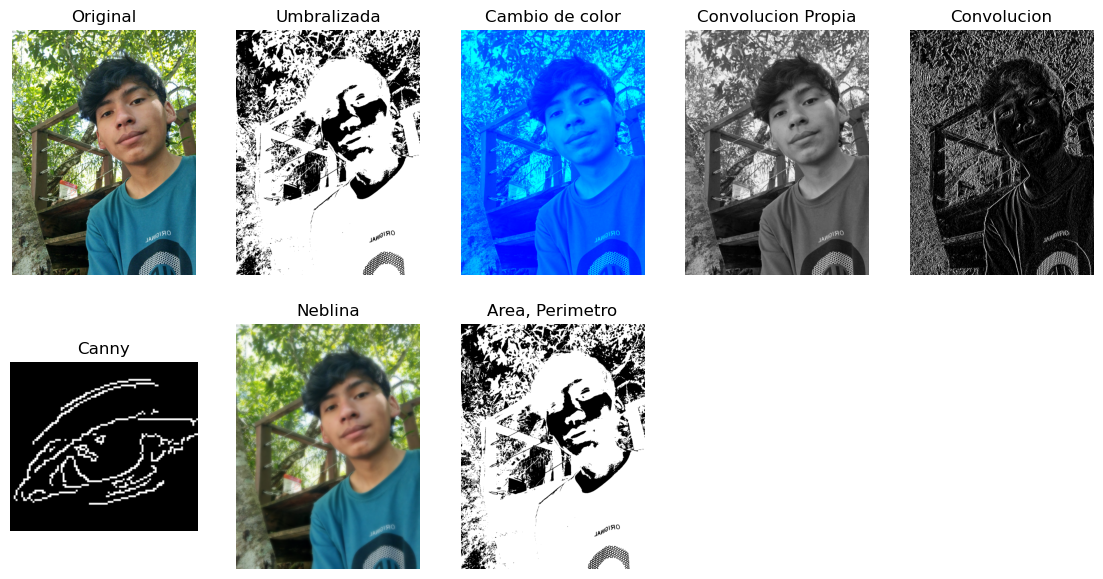

In [23]:
imgYo = cv2.imread('../img/ImgYo.jpg')
img_gray = cv2.cvtColor(imgYo, cv2.COLOR_BGR2GRAY)
imgYo_rgb = cv2.cvtColor(imgYo, cv2.COLOR_BGR2RGB)

#1
_, img_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
umbral_img_otsu = np.where(img_gray > img_otsu, 255, 0).astype(np.uint8)

#2
imgYoColor = cv2.applyColorMap(imgYo , cv2.COLORMAP_AUTUMN)

#3
maskSV = np.array([[1,0,0],[-1,1,1],[0,0,1]])/15 #kernel propio
img_conP = cv2.filter2D(img_gray,-1,maskSV)

#4
mask5 = np.array([[0,0,0],[-1,1,0],[0,0,0]])*21 #kernel realce de bordes
img_con5 = cv2.filter2D(img_gray,-1,mask5)

#5
img_ojo =  img_gray[380:470, 700:800]
ojo_canny = cv2.Canny(img_ojo,50,100)

#6
img_suav = cv2.GaussianBlur(imgYo, (41, 41), 0)
mask = np.ones_like(imgYo, dtype=np.float32)
mask *= 0.5
mask_suav = np.ones_like(imgYo, dtype=np.float32) * 0.7
img_empa = (imgYo * 0.3) + (img_suav * 0.7)
img_nieblina = cv2.cvtColor(img_empa.astype(np.uint8), cv2.COLOR_BGR2RGB)

#7
canny = cv2.Canny(img_gray,150,100)

#8
ret,bin=cv2.threshold(img_gray,255,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
contorno,jeraquia=cv2.findContours(bin,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
perimetros=[]
areaa=[]
for i in range(len(contorno)):
    cont=contorno[i]
    M=cv2.moments(cont)
    if M['m00']!=0:
        cx=int(M['m10']/M['m00'])
        cy=int(M['m01']/M['m00'])
    else:
        cx,cy=0,0
    area=cv2.contourArea(cont)*(2)
    perimetro=cv2.arcLength(cont,True)
    
    perimetros.append(perimetros)
    areaa.append(area)

    cv2.circle(imgYo,(cx,cy),5,(0,255,0),-1)
    x,y,w,h=cv2.boundingRect(cont)
    cv2.rectangle(imgYo,(x,y),(x+w,y+h),(255,0,255),3)


plt.figure(figsize=(14,7))
plt.subplot(2,5,1)
plt.title('Original')
plt.imshow(imgYo_rgb)
plt.axis('off')
plt.subplot(2,5,2)
plt.title('Umbralizada')
plt.imshow(umbral_img_otsu, cmap='gray')
plt.axis('off')
plt.subplot(2,5,3)
plt.title('Cambio de color')
plt.imshow(imgYoColor, cmap='gray')
plt.axis('off')
plt.subplot(2,5,4)
plt.title('Convolucion Propia')
plt.imshow(img_conP, cmap='gray')
plt.axis('off')
plt.subplot(2,5,5)
plt.title('Convolucion')
plt.imshow(img_con5, cmap='gray')
plt.axis('off')
plt.subplot(2,5,6)
plt.title('Canny')
plt.imshow(ojo_canny, cmap='gray')
plt.axis('off')
plt.subplot(2,5,7)
plt.title('Neblina')
plt.imshow(img_nieblina, cmap='gray')
plt.axis('off')
plt.subplot(2,5,8)
plt.title('Deteccion de bordes')
plt.imshow(canny, cmap='gray')
plt.axis('off')
plt.subplot(2,5,8)
plt.title('Area, Perimetro')
plt.imshow(bin, cmap='gray')
plt.axis('off')


Ejercicio 3

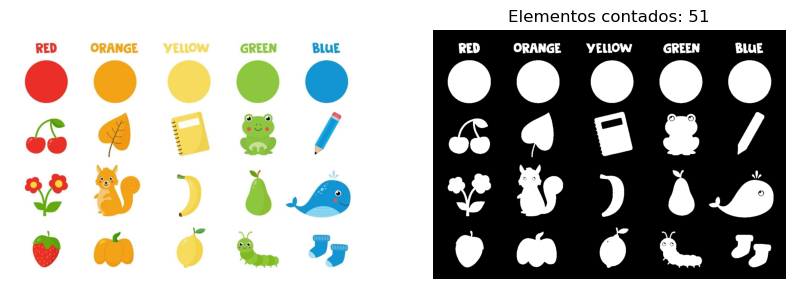

In [22]:
def conunt (img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  _,binarizada = cv2.threshold(img_gray, 230,255,cv2.THRESH_BINARY_INV)
  contorno = measure.label(binarizada, connectivity=2)
  cont = np.max(contorno)
  return cont, binarizada

img = cv2.imread('../img/colores.jpg')
cont, bin = conunt(img)

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(122)
plt.title(f'Elementos contados: {cont}')
plt.imshow(bin,cmap='gray')
plt.axis('off')
plt.show()